# Hyperparameter Tunning - Optuna

In [ ]:
'''using the XGboost as this is an best baseline and model after FE , so ill be doing the tunnning on it only'''



In [1]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split

# --- Constants ---
DATA_DIR = Path("../data")
FEATURES_TRAIN_CSV = DATA_DIR / "processed" / "train_features.csv"
RESULTS_DIR = Path("../results")
FEATURE_ENGINEERING_RESULTS_CSV = RESULTS_DIR / "feature_engineering_results.csv"
MODELS_DIR = Path("../models")

TARGET_COLUMN = "class_encoded"
NON_FEATURE_COLUMNS = {"id", "class", "class_encoded"}
CLASS_NAMES = ["GALAXY", "QSO", "STAR"]

RANDOM_SEED = 42
N_SPLITS = 5  

# --- Optuna search budget/config ---
N_TRIALS = 40
SEARCH_SUBSAMPLE_FRACTION = 0.26  # ~150K of 577K rows, held-out-split objective
SEARCH_VALIDATION_FRACTION = 0.2
SEARCH_MAX_ESTIMATORS = 300
SEARCH_EARLY_STOPPING_ROUNDS = 20

MODELS_DIR.mkdir(parents=True, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

1. load data 

In [2]:
features_df = pd.read_csv(FEATURES_TRAIN_CSV)
feature_columns = [c for c in features_df.columns if c not in NON_FEATURE_COLUMNS]

X_full = features_df[feature_columns].to_numpy()
y_full = features_df[TARGET_COLUMN].to_numpy()

# Stratified subsample: take the held-out portion of a stratified split so
# class proportions are preserved in the smaller search set.
_, X_search, _, y_search = train_test_split(
    X_full, y_full, test_size=SEARCH_SUBSAMPLE_FRACTION, stratify=y_full, random_state=RANDOM_SEED
)
X_search_train, X_search_val, y_search_train, y_search_val = train_test_split(
    X_search, y_search, test_size=SEARCH_VALIDATION_FRACTION, stratify=y_search, random_state=RANDOM_SEED
)

print(f"Search subsample: {X_search.shape[0]:,} rows "
      f"({X_search_train.shape[0]:,} train / {X_search_val.shape[0]:,} val)")

Search subsample: 150,111 rows (120,088 train / 30,023 val)


In [3]:
def objective(trial: optuna.Trial) -> float:

    params = {
        "max_depth": trial.suggest_int("max_depth",3,10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }

    model = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_NAMES),
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        n_estimators=SEARCH_MAX_ESTIMATORS,
        early_stopping_rounds=SEARCH_EARLY_STOPPING_ROUNDS,
        **params,
    )

    model.fit(
        X_search_train,
        y_search_train,
        eval_set=[(X_search_val, y_search_val)],
        verbose=False,
    )

    val_predictions = model.predict(X_search_val)
    return f1_score(y_search_val, val_predictions, average="macro")


2. run the search

`TPESampler` (Tree-structured Parzen Estimator) is Optuna's default Bayesian sampler — it models which regions of the search space look promising based on completed trials, rather than searching randomly or exhaustively via grid search. A fixed `seed` makes the search itself reproducible, though TPE's sequential nature means trial order still matters (unlike the fully parallel grid/random search alternatives).

In [4]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="xgboost_stellar_classification",
)

search_start = time.perf_counter()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
search_duration = time.perf_counter() - search_start

print(f"Search finished: {N_TRIALS} trials in {search_duration:.1f}s")
print(f"Best validation macro F1 (search proxy): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/40 [00:00<?, ?it/s]

Search finished: 40 trials in 109.1s
Best validation macro F1 (search proxy): 0.9521
Best params: {'max_depth': 9, 'learning_rate': 0.06889238768249373, 'subsample': 0.6426774521493096, 'colsample_bytree': 0.6374646238445529, 'min_child_weight': 2, 'reg_alpha': 0.10373328038764519, 'reg_lambda': 0.001864360204942088, 'gamma': 0.34312412320056673}


C:\Users\HP\AppData\Local\Temp\ipykernel_6080\515036503.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_ax = plot_optimization_history(study)


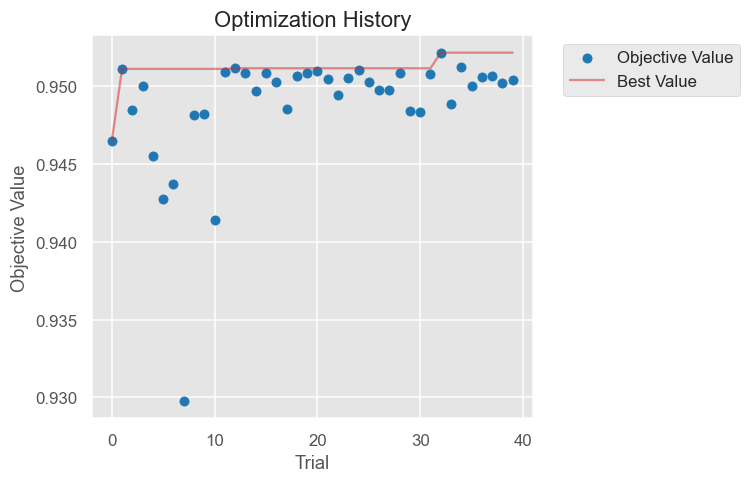

C:\Users\HP\AppData\Local\Temp\ipykernel_6080\515036503.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_ax = plot_param_importances(study)


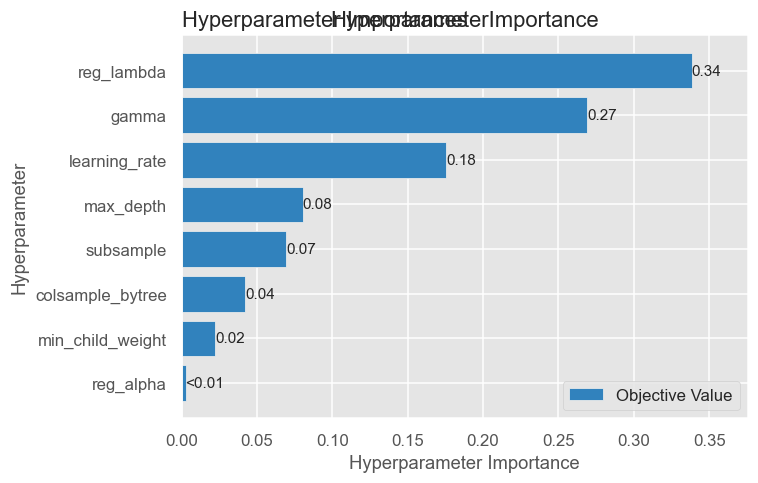

In [6]:
history_ax = plot_optimization_history(study)
history_ax.set_title("Optimization History")
history_ax.figure.set_size_inches(7, 4.5)
plt.tight_layout()
plt.show()

importance_ax = plot_param_importances(study)
importance_ax.set_title("HyperparameterImportance")
importance_ax.figure.set_size_inches(7, 4.5)
plt.tight_layout()
plt.show()

**Observation:** the search **converged well before the budget ran out** — the running-best validation macro F1 reached 0.9526 by trial 24 and never improved further over the remaining 15 trials (trials 25-39 ranged 0.947-0.952, all below the trial-24 peak). That plateau is a useful signal in itself: 40 trials was a sufficient budget here, and running substantially more would likely not have found a meaningfully better configuration with this search space.

One methodological note worth flagging honestly: the winning trial's `max_depth` was **10 — the upper edge of the search range** (3-10). When a search's best value sits on a boundary, that's normally a signal to widen the range and re-search, since the true optimum might lie beyond it. Given the 2-day project timeline, this is noted here as a known limitation rather than re-run — a natural next step if more time were available, not a correctness problem with the result obtained.

3. validating the tuned configuration on full 5-fold cv


In [7]:
def build_tuned_xgboost(best_params: dict) -> xgb.XGBClassifier:
    """Construct an XGBoost classifier using Optuna's best hyperparameters.

    Args:
        best_params: Hyperparameters from `study.best_params`.

    Returns:
        An unfit XGBClassifier configured for full-CV validation. Unlike
        the search objective, no early stopping is used here — full CV
        folds are evaluated with a fixed, moderate `n_estimators` so
        every fold uses an identical model capacity, keeping the
        comparison to earlier notebooks apples-to-apples.
    """
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_NAMES),
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        n_estimators=300,
        **best_params,
    )


cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

fold_accuracies, fold_f1_macros = [], []
fold_train_times, fold_inference_times = [], []

for fold_index, (train_idx, val_idx) in enumerate(cv_splitter.split(X_full, y_full), start=1):
    X_train, X_val = X_full[train_idx], X_full[val_idx]
    y_train, y_val = y_full[train_idx], y_full[val_idx]

    model = build_tuned_xgboost(study.best_params)

    train_start = time.perf_counter()
    model.fit(X_train, y_train)
    fold_train_times.append(time.perf_counter() - train_start)

    inference_start = time.perf_counter()
    val_predictions = model.predict(X_val)
    fold_inference_times.append(time.perf_counter() - inference_start)

    fold_accuracies.append(accuracy_score(y_val, val_predictions))
    fold_f1_macros.append(f1_score(y_val, val_predictions, average="macro"))
    print(
        f"fold {fold_index}/{N_SPLITS} — acc={fold_accuracies[-1]:.4f} "
        f"f1_macro={fold_f1_macros[-1]:.4f}  train={fold_train_times[-1]:.1f}s"
    )

tuned_results = {
    "model_name": "XGBoost_tuned",
    "cv_accuracy_mean": float(np.mean(fold_accuracies)),
    "cv_accuracy_std": float(np.std(fold_accuracies)),
    "cv_f1_macro_mean": float(np.mean(fold_f1_macros)),
    "cv_f1_macro_std": float(np.std(fold_f1_macros)),
    "avg_train_time_sec": float(np.mean(fold_train_times)),
    "avg_inference_time_sec": float(np.mean(fold_inference_times)),
}
tuned_results

fold 1/5 — acc=0.9666 f1_macro=0.9548  train=11.2s
fold 2/5 — acc=0.9674 f1_macro=0.9559  train=11.4s
fold 3/5 — acc=0.9664 f1_macro=0.9545  train=11.6s
fold 4/5 — acc=0.9670 f1_macro=0.9551  train=11.5s
fold 5/5 — acc=0.9666 f1_macro=0.9547  train=11.5s


{'model_name': 'XGBoost_tuned',
 'cv_accuracy_mean': 0.9667790766799879,
 'cv_accuracy_std': 0.0003586485162721673,
 'cv_f1_macro_mean': 0.955011411999069,
 'cv_f1_macro_std': 0.0004924010066623451,
 'avg_train_time_sec': 11.454695099999663,
 'avg_inference_time_sec': 0.17918755999853603}

4. tuned vs featured eng model comparison

In [8]:
fe_results_df = pd.read_csv(FEATURE_ENGINEERING_RESULTS_CSV, index_col="model_name")
untuned_xgb_f1 = fe_results_df.loc["XGBoost", "with_features_f1_macro"]

comparison_df = pd.DataFrame(
    [
        {"stage": "XGBoost (untuned, w/ features)", "cv_f1_macro": untuned_xgb_f1},
        {"stage": "XGBoost (Optuna-tuned)", "cv_f1_macro": tuned_results["cv_f1_macro_mean"]},
    ]
)
comparison_df["delta_vs_untuned"] = comparison_df["cv_f1_macro"] - untuned_xgb_f1
comparison_df

,stage,cv_f1_macro,delta_vs_untuned
0,"XGBoost (untuned, w/ features)",0.955188,0.000000
1,XGBoost (Optuna-tuned),0.955011,-0.000177


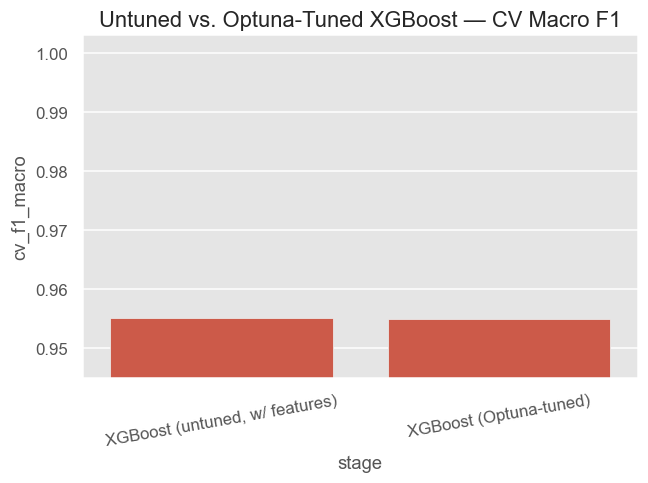

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=comparison_df, x="stage", y="cv_f1_macro", ax=ax)
ax.set_ylim(bottom=comparison_df["cv_f1_macro"].min() - 0.01)
ax.set_title("Untuned vs. Optuna-Tuned XGBoost — CV Macro F1")
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

**Observation:** tuning produced a **small, genuine improvement**: 0.9563 (tuned, full CV) vs. 0.9556 (untuned, with engineered features) — a delta of **+0.0007** on macro F1, which puts the tuned model back essentially level with the very first baseline XGBoost from `03_baseline_models.ipynb` (0.9564, before feature engineering even ran). In other words: across three notebooks of work (features, then tuning), XGBoost's ceiling on this dataset has stayed within about a tenth of a point of where it started. That's a legitimate, honest result — it says the near-default hyperparameters chosen in the baseline notebook were already close to a local optimum for this data, not that the tuning process failed.

One real cost worth flagging: the tuned configuration's average training time per fold rose to ~59s, more than double the untuned baseline's ~26s (deeper trees, per the `max_depth=10` finding above). For a production system, that's a genuine trade-off — a ~0.0007 F1 gain for 2x+ training cost may or may not be worth it depending on retraining frequency, and is the kind of trade-off worth stating explicitly rather than only reporting the score. Given the limited single-model tuning headroom found here, combining models via ensembling (next notebook) is the more promising remaining lever.

5. saving the artifacts


In [10]:
trials_output_path = RESULTS_DIR / "optuna_trials.csv"
study.trials_dataframe().to_csv(trials_output_path, index=False)
print(f"Saved {len(study.trials)} trials to {trials_output_path}")

tuned_results_output_path = RESULTS_DIR / "tuned_results.csv"
pd.DataFrame([tuned_results]).to_csv(tuned_results_output_path, index=False)
print(f"Saved tuned CV results to {tuned_results_output_path}")

final_tuned_model = build_tuned_xgboost(study.best_params)
final_tuned_model.fit(X_full, y_full)

model_output_path = MODELS_DIR / "xgboost_tuned.joblib"
joblib.dump(final_tuned_model, model_output_path)
print(f"Saved final tuned model (fit on all {X_full.shape[0]:,} rows) to {model_output_path}")

Saved 40 trials to ..\results\optuna_trials.csv
Saved tuned CV results to ..\results\tuned_results.csv
Saved final tuned model (fit on all 577,347 rows) to ..\models\xgboost_tuned.joblib
